In [94]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

df = pd.read_csv('winequality-red.csv', delimiter=';')

df.info()
df.dropna(inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1598 non-null   float64
 1   volatile acidity      1598 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1598 non-null   float64
 4   chlorides             1598 non-null   float64
 5   free sulfur dioxide   1598 non-null   float64
 6   total sulfur dioxide  1598 non-null   float64
 7   density               1598 non-null   float64
 8   pH                    1598 non-null   float64
 9   sulphates             1598 non-null   float64
 10  alcohol               1598 non-null   float64
 11  quality               1598 non-null   float64
dtypes: float64(12)
memory usage: 150.0 KB


In [95]:
imputer = KNNImputer(n_neighbors=2)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
df_numerical = df[numerical_cols]
df_imputed = imputer.fit_transform(df_numerical)
df_imputed

# Run only once....
# imputer = KNNImputer(n_neighbors=2)
# df_imputed = imputer.fit_transform(df)
# df_imputed = pd.DataFrame(df_imputed, columns=df.columns)
# df_imputed.isnull().sum()
# df_imputed.to_csv("winequality-red-imputed.csv", index=False)

array([[ 7.8  ,  0.88 ,  0.   , ...,  0.68 ,  9.8  ,  5.   ],
       [ 7.8  ,  0.76 ,  0.04 , ...,  0.65 ,  9.8  ,  5.   ],
       [11.2  ,  0.28 ,  0.56 , ...,  0.58 ,  9.8  ,  6.   ],
       ...,
       [ 5.9  ,  0.55 ,  0.1  , ...,  0.76 , 11.2  ,  6.   ],
       [ 6.3  ,  0.51 ,  0.13 , ...,  0.75 , 11.   ,  6.   ],
       [ 5.9  ,  0.645,  0.12 , ...,  0.71 , 10.2  ,  5.   ]])

### Hypotheses to Test in Wine Quality Dataset
Based on the correlation matrix, we found that **alcohol**, **volatile acidity**, **citric acid**, and **sulfur dioxide** have a moderate relationship with **quality**. These hypotheses are made to see if these relationships are true or not.
1. **Higher Alcohol Content is Associated with Better Quality**: Based on the correlation matrix, alcohol is positively correlated with quality.
2. **Volatile Acidity Negatively Impacts Wine Quality**: Higher volatile acidity might be a negative attribute based on its negative correlation with quality.
3. **Higher Citric Acid Level Contributes to Higher Quality**: Citric acid has a moderate positive correlation, indicating it could improve taste and quality.
4. **Sulfur Dioxide Levels Affect Quality**: Wines with an optimal balance of free and total sulfur dioxide are hypothesized to have better ratings.


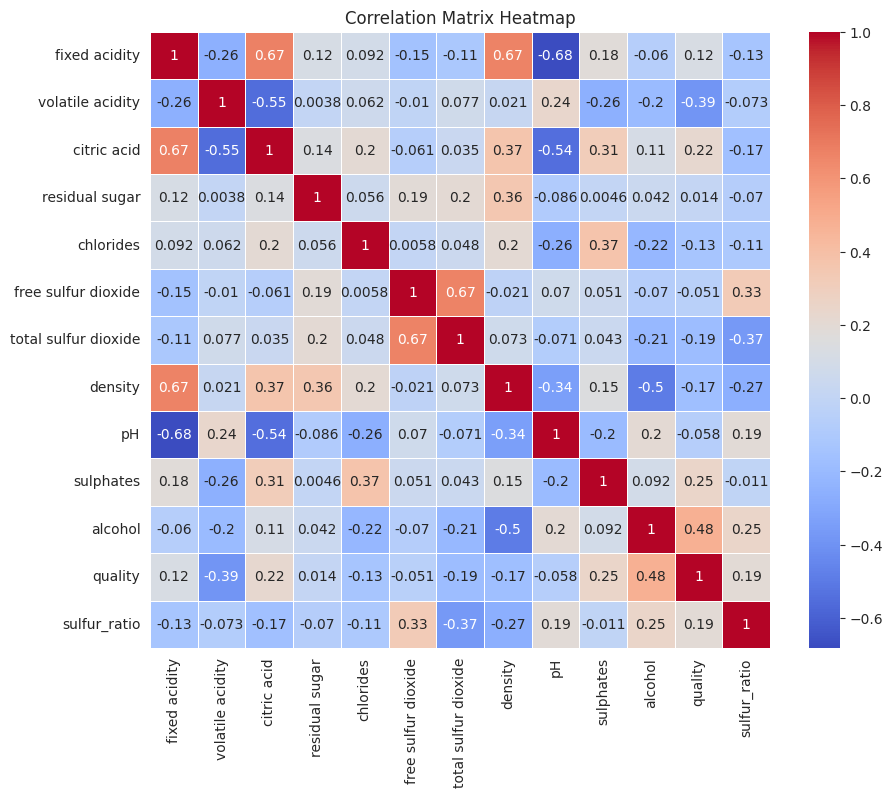

In [111]:
# Correlation Matrex
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

### Hypothesis 1: "Higher alcohol content is linked to better wine quality."

The line in the scatter plot goes up, which means wines with more alcohol usually have better quality.

We also did a **T-test** to compare alcohol content between high-quality wines (quality ≥ 7) and low-quality wines (quality ≤ 4). The **p-value** was very small (`1.3e-17`), which means the difference is real and not by chance.

This confirms that more alcohol is linked to better wine quality.


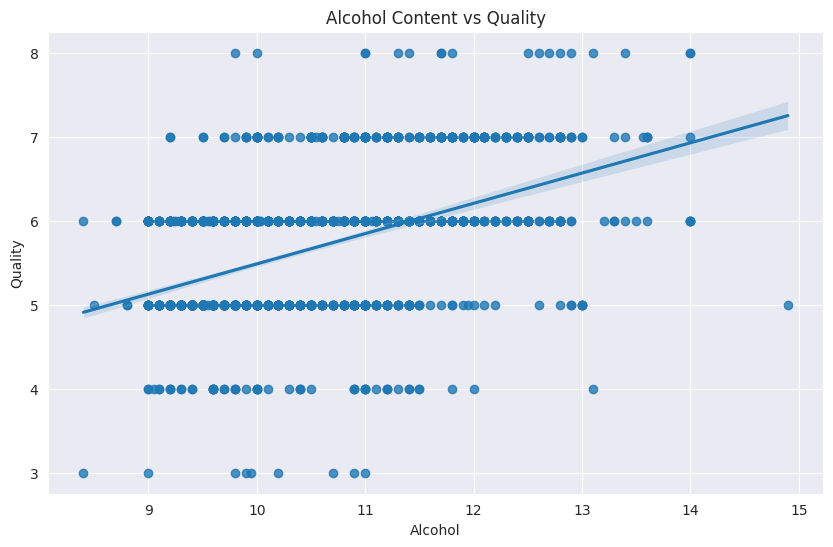

In [96]:
plt.figure(figsize=(10, 6))
sns.regplot(x='alcohol', y='quality', data=df)
plt.title('Alcohol Content vs Quality')
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.show()

In [97]:
from scipy.stats import ttest_ind

high_quality = df[df['quality'] >= 7]['alcohol']
low_quality = df[df['quality'] <= 4]['alcohol']

# T-test to see if there's a significant difference in alcohol content
t_stat, p_value = ttest_ind(high_quality, low_quality)
print(f"T-statistic: {t_stat}, P-value: {p_value}")


T-statistic: 9.14807584367848, P-value: 1.2982597417642084e-17


### Hypothesis 2: "Volatile acidity negatively impacts wine quality."

The box plot shows that when **volatile acidity** is lower, **wine quality** is usually higher. High-quality wines (7 and 8) have **less volatile acidity** compared to low-quality wines (3 and 4).

This means that **lower volatile acidity** is linked to **better wine quality**.


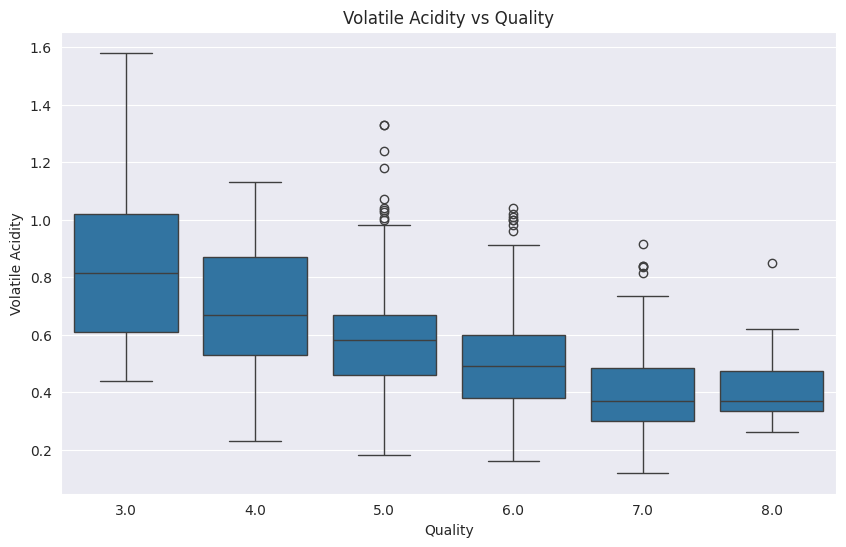

In [98]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='volatile acidity', data=df)
plt.title('Volatile Acidity vs Quality')
plt.xlabel('Quality')
plt.ylabel('Volatile Acidity')
plt.show()


### Hypothesis 3: "Higher citric acid level contributes to higher quality."

The scatter plot shows a **small positive trend**—as **citric acid** goes up, **wine quality** also gets a bit better.

The box plot shows that **high-quality wines** (7 and 8) have **more citric acid** compared to lower quality wines (3 and 4), but the difference isn't very big.

So, **more citric acid** seems to be linked to **better quality**, but the effect is **not very strong**.


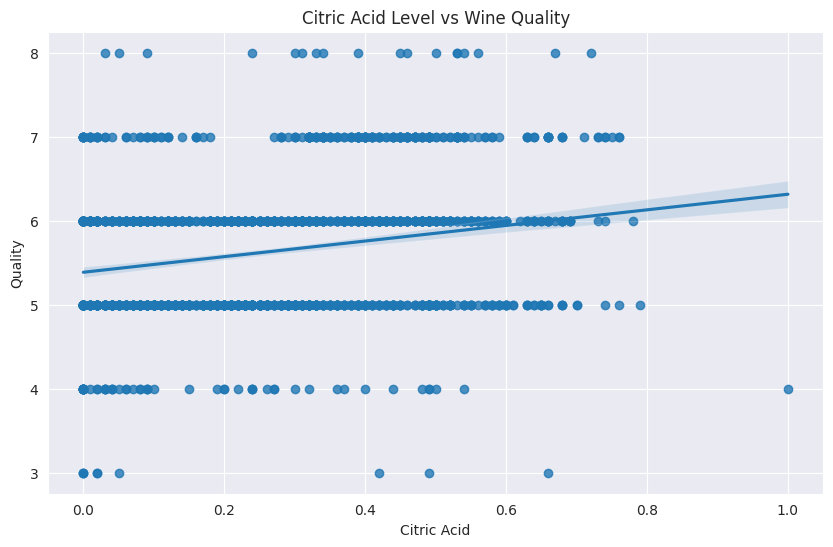

In [99]:
plt.figure(figsize=(10, 6))
sns.regplot(x='citric acid', y='quality', data=df)
plt.title('Citric Acid Level vs Wine Quality')
plt.xlabel('Citric Acid')
plt.ylabel('Quality')
plt.show()


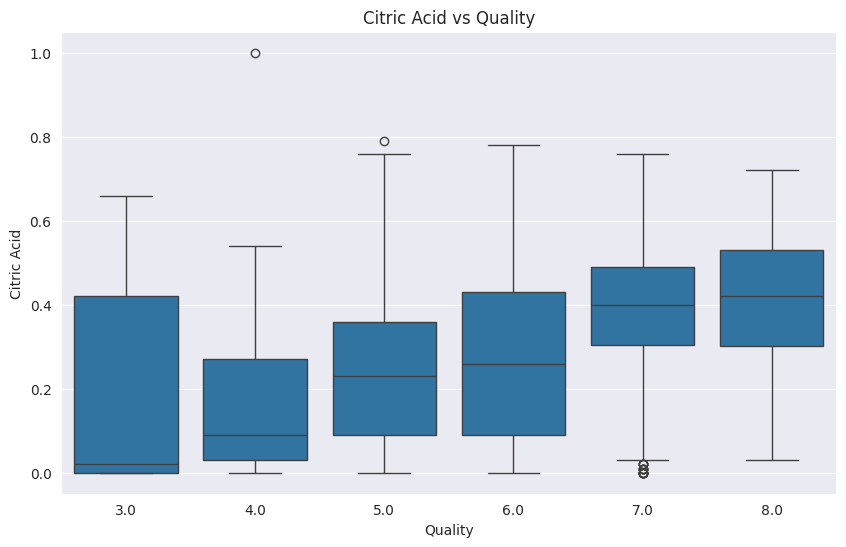

In [100]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='citric acid', data=df)
plt.title('Citric Acid vs Quality')
plt.xlabel('Quality')
plt.ylabel('Citric Acid')
plt.show()

### Hypothesis 4: "Sulfur dioxide levels affect quality."

- The **box plot for free sulfur dioxide** shows that the levels are **about the same** across different quality ratings. High-quality wines (7 and 8) have **a bit less** free sulfur dioxide, but the difference is small.

- The **box plot for total sulfur dioxide** shows a similar pattern. High-quality wines (7 and 8) have **less total sulfur dioxide** compared to lower-quality wines, but the difference is also **not big**.

- The **scatter plot of sulfur ratio** (free to total sulfur dioxide) does not show a clear trend. The values are **spread out** across all quality levels.

In short, **lower sulfur dioxide levels** might be linked to **better wine quality**, but the effect is **not very strong**. The balance of sulfur dioxide does **not seem** to clearly affect the quality.


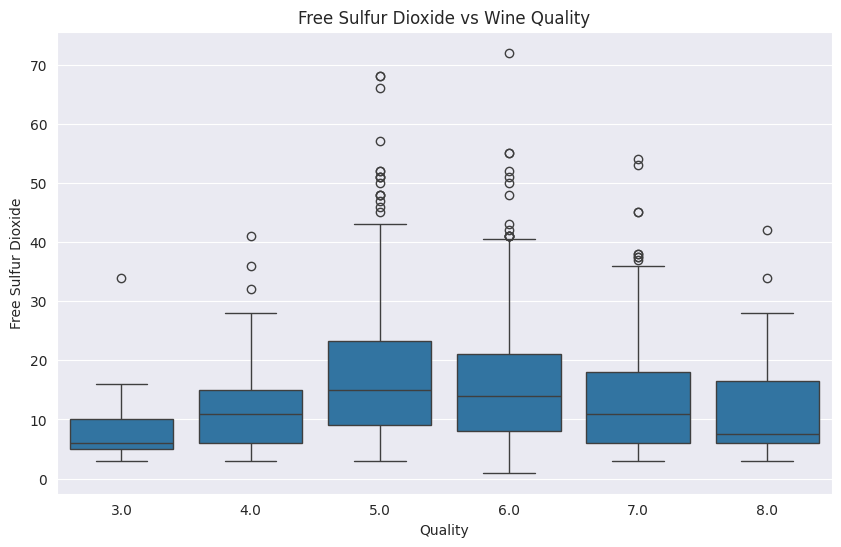

In [106]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='free sulfur dioxide', data=df)
plt.title('Free Sulfur Dioxide vs Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Free Sulfur Dioxide')
plt.show()


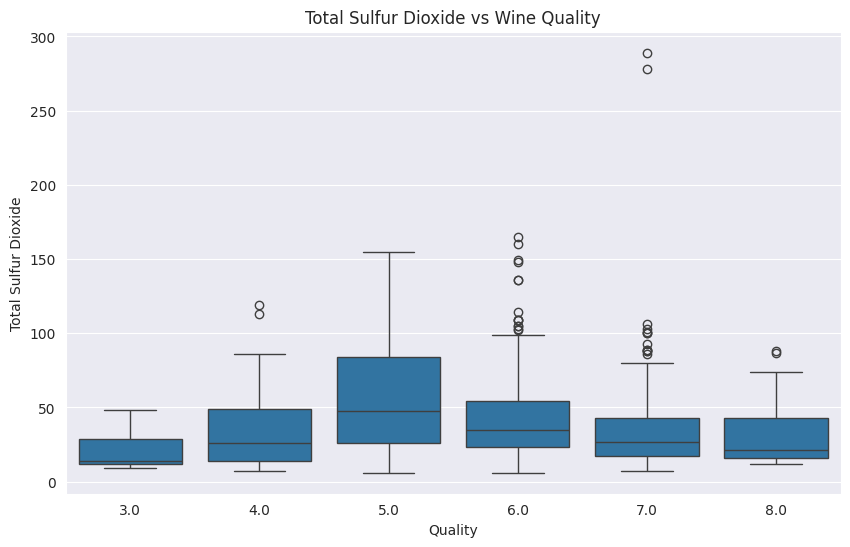

In [109]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='total sulfur dioxide', data=df)
plt.title('Total Sulfur Dioxide vs Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Total Sulfur Dioxide')
plt.show()


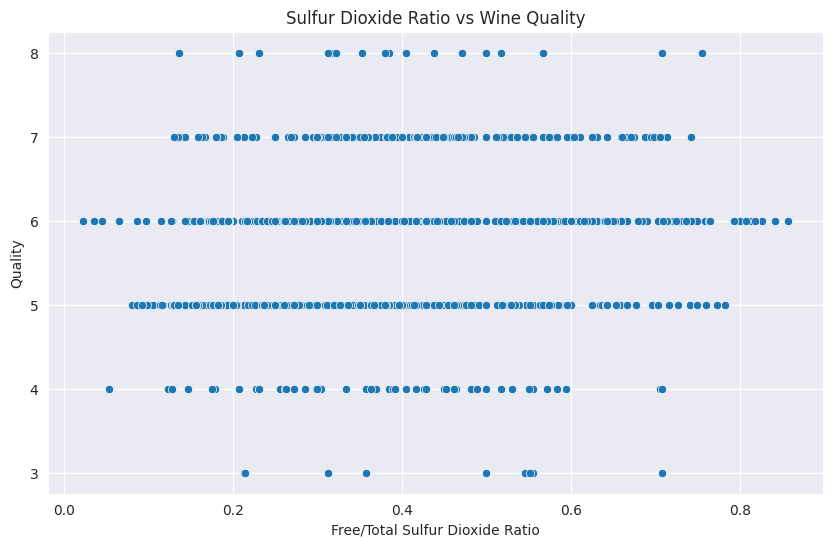

In [110]:
df['sulfur_ratio'] = df['free sulfur dioxide'] / df['total sulfur dioxide']

plt.figure(figsize=(10, 6))
sns.scatterplot(x='sulfur_ratio', y='quality', data=df)
plt.title('Sulfur Dioxide Ratio vs Wine Quality')
plt.xlabel('Free/Total Sulfur Dioxide Ratio')
plt.ylabel('Quality')
plt.show()


In [102]:
# Define features (X) and target (y)
X = df.drop(columns=['quality'])  # Features: All columns except 'quality'
y = df['quality']                 # Target: 'quality'

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Use SelectKBest to select top 5 features based on f_regression
selector = SelectKBest(score_func=f_classif, k=3)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Train a RandomForestClassifier on the selected features
model = RandomForestClassifier(random_state=42)
model.fit(X_train_selected, y_train)

# Predict and evaluate performance using Mean Squared Error (MSE)
y_pred = model.predict(X_test_selected)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error with selected features: {mse:.4f}")

# Get the selected feature names
selected_features = X.columns[selector.get_support()]
print("\nSelected Features classification:\n", selected_features)

Mean Squared Error with selected features: 0.4717

Selected Features classification:
 Index(['volatile acidity', 'total sulfur dioxide', 'alcohol'], dtype='object')


In [103]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Use SelectKBest to select top 5 features based on f_regression
selector = SelectKBest(score_func=f_regression, k=3)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Train a RandomForestRegressor on the selected features
model = RandomForestRegressor(random_state=42)
model.fit(X_train_selected, y_train)

# Predict and evaluate performance using Mean Squared Error (MSE)
y_pred = model.predict(X_test_selected)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error with selected features: {mse:.4f}")

# Get the selected feature names
selected_features = X.columns[selector.get_support()]
print("\nSelected Features regression:\n", selected_features)

Mean Squared Error with selected features: 0.3757

Selected Features regression:
 Index(['volatile acidity', 'sulphates', 'alcohol'], dtype='object')


#### To identify the best features that explain the most variance in the dataset, I analyzed the feature loadings for the top few principal components (PCs) that capture the highest explained variance. Based on the loadings for the first three principal components, which together account for approximately 59.74% of the total variance, the most significant features are **fixed acidity**, **citric acid**, **density**, **pH**, **free sulfur dioxide**, **total sulfur dioxide**, **alcohol**, and **volatile acidity**. These features were selected because they exhibit the highest loadings (positive or negative) across the first three PCs, indicating their strong contribution to the overall variance in the data. Choosing these features allows us to retain the most critical information while simplifying the model, making it suitable for further analysis or predictive modeling.

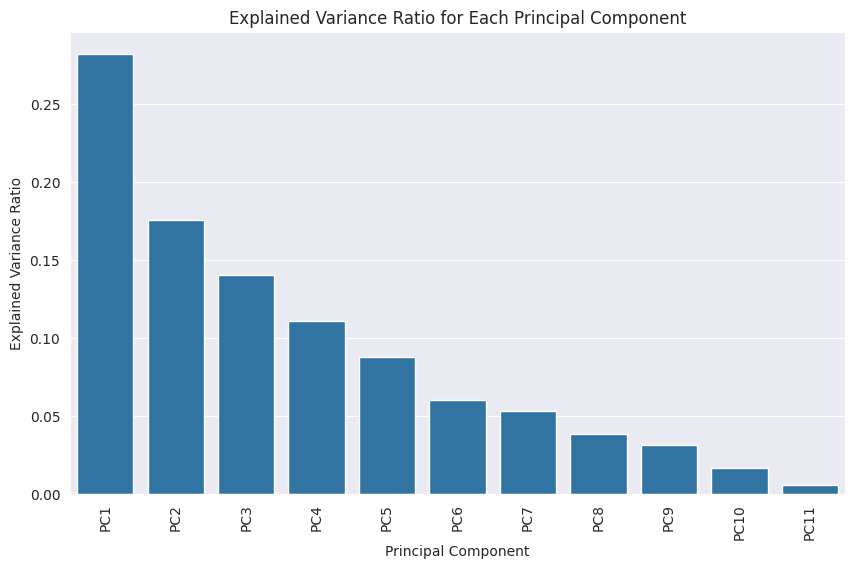


Feature Loadings onto Principal Components:
                           PC1       PC2       PC3       PC4       PC5  \
fixed acidity         0.489259 -0.111130 -0.122611 -0.229792 -0.082347   
volatile acidity     -0.238496  0.276368 -0.449824  0.078119  0.216979   
citric acid           0.464286 -0.153186  0.235258 -0.078235 -0.058151   
residual sugar        0.146256  0.269446  0.097046 -0.373249  0.732834   
chlorides             0.211566  0.148786 -0.093633  0.665525  0.246432   
free sulfur dioxide  -0.035116  0.512548  0.432806 -0.045766 -0.153356   
total sulfur dioxide  0.025592  0.569369  0.323730 -0.035257 -0.221181   
density               0.395444  0.232804 -0.339989 -0.174528  0.155939   
pH                   -0.438374  0.006483  0.054524 -0.004464  0.267100   
sulphates             0.242381 -0.038133  0.278896  0.551207  0.228677   
alcohol              -0.113348 -0.387926  0.469706 -0.122831  0.352976   

                           PC6       PC7       PC8       PC9      

In [104]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


# separating out the features and the target variable (quality)
features = df.columns[:-1]  # adding columns except 'quality'
x = df.loc[:, features].values
y = df.loc[:, ['quality']].values  # target variable (quality)

# standardizing the features
x = StandardScaler().fit_transform(x)

# applying PCA to retain all components
pca = PCA(n_components=len(features))  # using all features
principal_components = pca.fit_transform(x)

# explained variance ratio for each principal component
explained_variance_ratio = pca.explained_variance_ratio_

# create a DataFrame to store the explained variance ratio for each component
explained_variance_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(features))],
    'Explained Variance Ratio': explained_variance_ratio
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Principal Component', y='Explained Variance Ratio', data=explained_variance_df)

plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio for Each Principal Component')

plt.xticks(rotation=90)  # Rotate the labels for better readability
plt.show()

loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(features))], index=features)
print("\nFeature Loadings onto Principal Components:")
print(loadings)
